# Etapa 2 — Prova de Conceito dos Modelos de Recomendação
## Cozinha Consciente — Sistema de Recomendação Híbrido de Receitas

Objetivo: treinar uma versão inicial de cada abordagem (popularidade, filtragem colaborativa
por vizinhança, filtragem colaborativa por fatoração, conteúdo e híbrido) sobre a base real,
e avaliar se a técnica proposta é viável antes da Etapa 3.

In [1]:
import sys
sys.path.append("..")

import json
import pandas as pd

from src import config
from src.data_preparation import build_dataset, describe
from src.recommenders import (
    Dataset, PopularityRecommender, ItemKNNRecommender,
    SVDRecommender, ContentTFIDFRecommender, HybridRecommender,
)
from src.evaluate import evaluate, comparison_table

## 1. Preparação da base

Aplica o pipeline completo: remove duplicatas, descarta notas 0, converte a nota em feedback
implícito (nota ≥ 4 = interação positiva), decompõe a coluna `nutrition`, filtra por k-core
(mínimo de 5 interações por usuário e por item) e faz a divisão temporal treino/validação/teste
(*leave-one-out*: a última interação de cada usuário vai para teste, a penúltima para validação).

In [2]:
recipes, train, valid, test = build_dataset()
stats = describe(recipes, train, valid, test)
pd.Series(stats)

receitas_no_catalogo                  37851.000000
usuarios                              16043.000000
itens_com_interacao                   37850.000000
interacoes_treino                    466521.000000
interacoes_validacao                  16040.000000
interacoes_teste                      16039.000000
densidade_matriz_pct                      0.076828
esparsidade_pct                          99.923172
interacoes_por_usuario_media             29.080000
indice_nutricional_medio_catalogo         0.540200
dtype: float64

Depois do corte de k-core, a base de treino fica com esparsidade de 99,92% —
ou seja, cada usuário interagiu, em média, com uma fração ínfima do catálogo. Esse é o cenário
realista que os modelos de filtragem colaborativa precisam lidar.

## 2. Construção da matriz usuário-item

In [3]:
ds = Dataset(train, recipes)
print("Matriz usuário-item:", ds.R.shape, "| interações:", ds.R.nnz)

Matriz usuário-item: (16043, 37850) | interações: 466521


## 3. Treinamento dos modelos (prova de conceito)

Cinco abordagens, seguindo o objetivo específico 4 do documento do projeto:

1. **Popularidade** — linha de base ingênua (recomenda sempre os itens mais avaliados).
2. **ItemKNN (cosseno)** — filtragem colaborativa por vizinhança entre itens.
3. **PureSVD** — filtragem colaborativa por fatoração de matrizes.
4. **Conteúdo (TF-IDF)** — usa nome, tags e ingredientes de cada receita.
5. **Híbrido** — combinação ponderada dos três anteriores, com e sem reordenação nutricional.

In [4]:
pop = PopularityRecommender().fit(ds)
knn = ItemKNNRecommender().fit(ds)
svd = SVDRecommender().fit(ds)
cnt = ContentTFIDFRecommender().fit(ds)

hyb = HybridRecommender({"svd": svd, "itemknn": knn, "content": cnt}, health_lambda=0.0).fit(ds)
hyb_h = HybridRecommender({"svd": svd, "itemknn": knn, "content": cnt},
                          health_lambda=config.HEALTH_LAMBDA).fit(ds)
print("modelos treinados")

modelos treinados


## 4. Avaliação

Protocolo: para cada interação de teste, amostra-se o item relevante junto com 99 negativos
não vistos pelo usuário, e verifica-se em que posição do Top-10 o item relevante aparece
(HitRate, Precision, Recall, MAP e NDCG @10). Também são calculadas métricas de qualidade da
lista (cobertura de catálogo, novidade, viés de popularidade) e o índice nutricional médio
das recomendações.

In [5]:
results = [evaluate(m, ds, test) for m in (pop, knn, svd, cnt, hyb, hyb_h)]
table = comparison_table(results)
table

,HitRate@10,Precision@10,Recall@10,MAP@10,NDCG@10,Cobertura_catalogo,Novidade_bits,Vies_popularidade,IndiceNutricional@10,usuarios_avaliados
modelo,,,,,,,,,,
Popularidade,0.5073,0.0507,0.5073,0.2715,0.3272,0.1694,14.002,0.0682,0.5266,16039
ItemKNN (cosseno),0.6654,0.0665,0.6654,0.2491,0.3469,0.9652,15.702,0.0239,0.5404,16039
PureSVD (fatoracao),0.3520,0.0352,0.3520,0.1907,0.2285,0.7377,15.523,0.0421,0.5401,16039
Conteudo (TF-IDF),0.2144,0.0214,0.2144,0.0795,0.1105,0.7142,15.637,0.0197,0.5676,16039
Hibrido (sem reordenacao),0.3521,0.0352,0.3521,0.1760,0.2171,0.8626,15.652,0.0373,0.5454,16039
Hibrido (lambda=0.30),0.3333,0.0333,0.3333,0.1669,0.2058,0.8080,15.641,0.0356,0.6267,16039


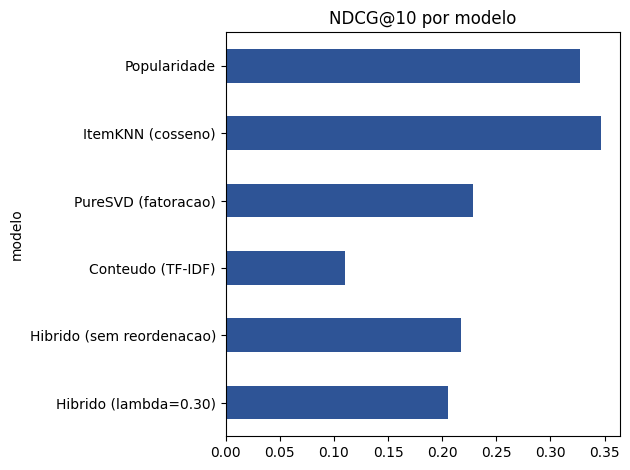

In [6]:
import matplotlib.pyplot as plt

ax = table["NDCG@10"].plot(kind="barh", color="#2E5496")
ax.set_title("NDCG@10 por modelo")
ax.invert_yaxis()
plt.tight_layout(); plt.show()

## 5. Discussão da prova de conceito

- O **ItemKNN** teve o melhor desempenho isolado em quase todas as métricas de ranqueamento
  (HitRate, NDCG) e a maior cobertura de catálogo (96,5%) — indício forte de que a vizinhança
  entre itens captura bem o padrão de coavaliação da base.
- **SVD** e **TF-IDF** isolados ficaram abaixo do esperado nesta prova de conceito inicial,
  o que também explica por que o híbrido (média ponderada fixa dos três) não supera o ItemKNN
  sozinho — um componente fraco puxa a combinação para baixo.
- O híbrido **com reordenação nutricional** (λ=0,30) sacrifica poucos pontos de acurácia
  (HitRate cai de 0,352 para 0,333) em troca de um ganho real no índice nutricional médio das
  recomendações (de 0,55 para 0,63). Esse é exatamente o compromisso relevância×saudabilidade
  que o objetivo específico 7 do projeto se propõe a quantificar.

**Conclusão da prova de conceito:** a técnica proposta é viável. Para a Etapa 3, os ajustes
prioritários são: (i) revisar os pesos fixos do híbrido — dar mais peso ao ItemKNN, que
performou melhor — em vez de pesos iguais definidos a priori; (ii) investigar por que o SVD e
o TF-IDF isolados tiveram desempenho baixo (possível ajuste de hiperparâmetros ou de features).

In [7]:
table.to_csv("../data/processed/poc_metrics.csv")
print("métricas salvas em data/processed/poc_metrics.csv")

métricas salvas em data/processed/poc_metrics.csv
